In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [4]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelength')

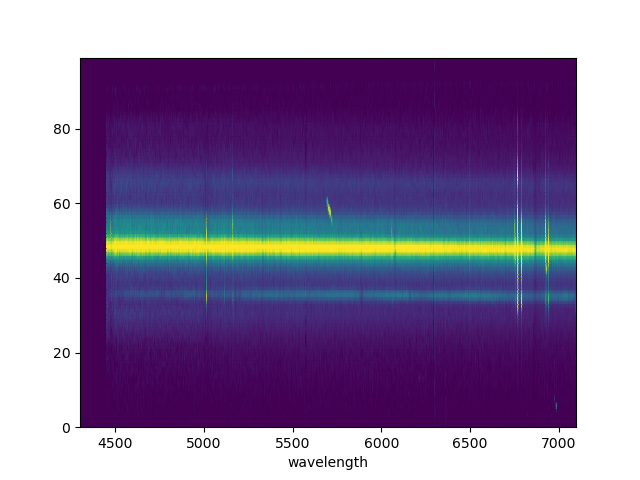

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

In [6]:
z = 0.03191
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/PSF/Real_seeing_NGC3217_2.txt")
sigma = seeing[0] / 2.35

In [7]:
l_HA

6772.425330000001

Text(0.5, 1.0, 'H$\\alpha$')

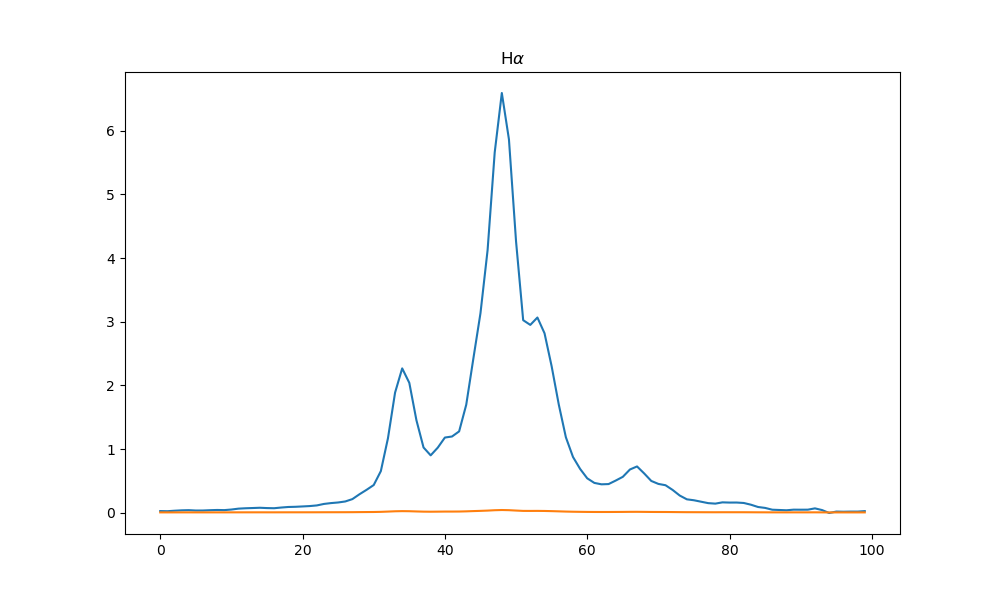

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100  
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 224.63316815237033
differential_evolution step 2: f(x)= 212.08890719088902
differential_evolution step 3: f(x)= 164.46846247414103
differential_evolution step 4: f(x)= 151.66507973992233
differential_evolution step 5: f(x)= 151.66507973992233
differential_evolution step 6: f(x)= 147.82050658517616
differential_evolution step 7: f(x)= 145.77170582709488
differential_evolution step 8: f(x)= 132.02350004375475
differential_evolution step 9: f(x)= 131.83783493987147
differential_evolution step 10: f(x)= 118.96513391556515
differential_evolution step 11: f(x)= 114.93216676655237
differential_evolution step 12: f(x)= 114.93216676655237
differential_evolution step 13: f(x)= 112.65322225965005
differential_evolution step 14: f(x)= 112.65322225965005
differential_evolution step 15: f(x)= 112.37362450223804
differential_evolution step 16: f(x)= 112.37362450223804
differential_evolution step 17: f(x)= 111.08836135380872
differential_evolution step 18: f(x)= 10

Optimize parameters with curve fit:
Sérsic 1: I_e=0.4453, r_e=17.3078, n=1.6976, x_0=48.2251
[0.09022536 2.01949915 0.20771121 0.0857615 ]
237.79055815400352
246.21161078558248 0.0 256.21123889795587 4


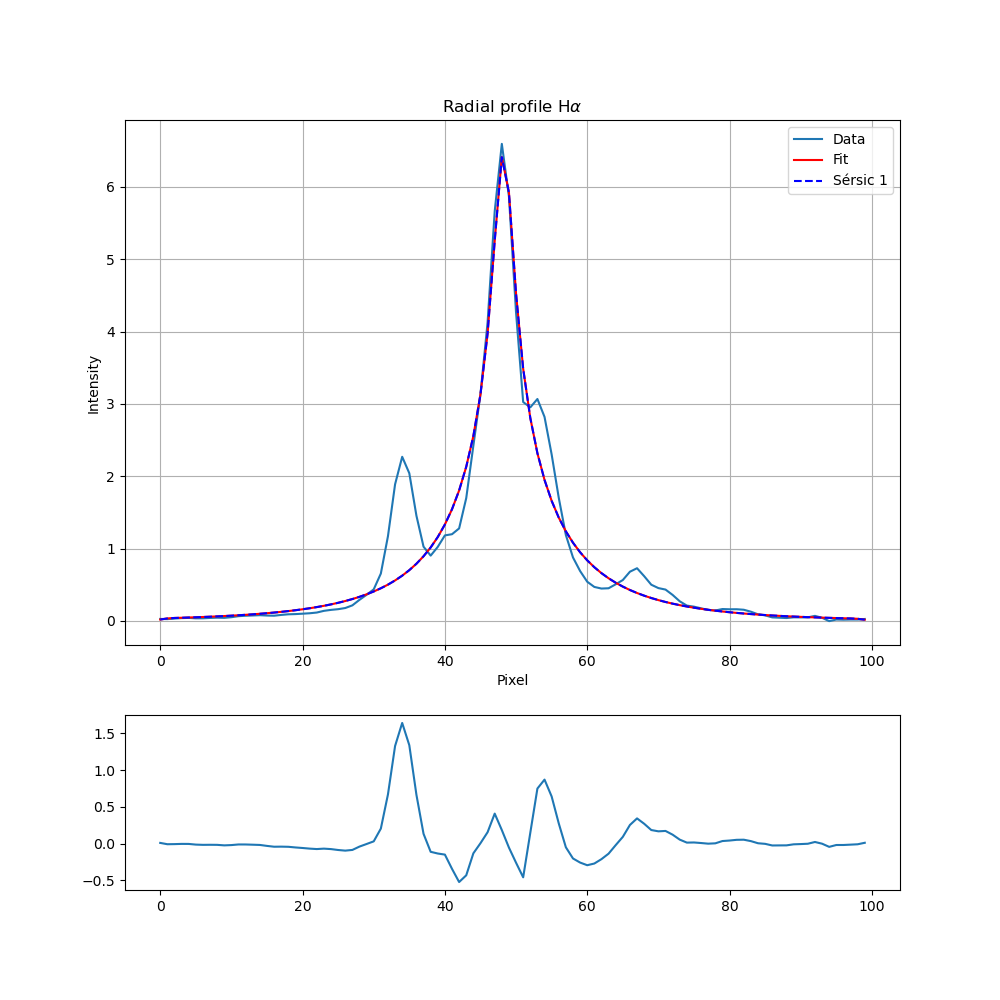

In [11]:
# Plots:
aic = np.zeros(7)
bic = np.zeros(7)
chi_quadr = np.zeros(7)
chi_quadro = np.zeros(7)
red_chi = np.zeros(7)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),  
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 1874.963641376167
differential_evolution step 2: f(x)= 457.0839915128148
differential_evolution step 3: f(x)= 188.1132320234705
differential_evolution step 4: f(x)= 131.1121372204289
differential_evolution step 5: f(x)= 41.675020599534456
differential_evolution step 6: f(x)= 41.675020599534456
differential_evolution step 7: f(x)= 41.675020599534456
differential_evolution step 8: f(x)= 41.675020599534456
differential_evolution step 9: f(x)= 30.51226937393961
differential_evolution step 10: f(x)= 30.51226937393961
differential_evolution step 11: f(x)= 30.51226937393961
differential_evolution step 12: f(x)= 10.000372390498985
differential_evolution step 13: f(x)= 10.000372390498985
differential_evolution step 14: f(x)= 10.000372390498985
differential_evolution step 15: f(x)= 10.000372390498985
differential_evolution step 16: f(x)= 10.000372390498985
differential_evolution step 17: f(x)= 10.000372390498985
differential_evolution step 18: f(x)= 10.000372

Optimize parameters with curve fit:
Sérsic 1: I_e=1.1172, r_e=1.4612, n=0.4312, x_0=33.9763
Sérsic 2: I_e=0.4331, r_e=16.6288, n=1.7455, x_0=48.3155
[0.53946245 0.24880667 0.38517585 0.15278974 0.05252916 1.23277506
 0.09902521 0.1013591 ]
98.61654028180463
116.19895786422221 98.61654028180463 135.45790176970937 8


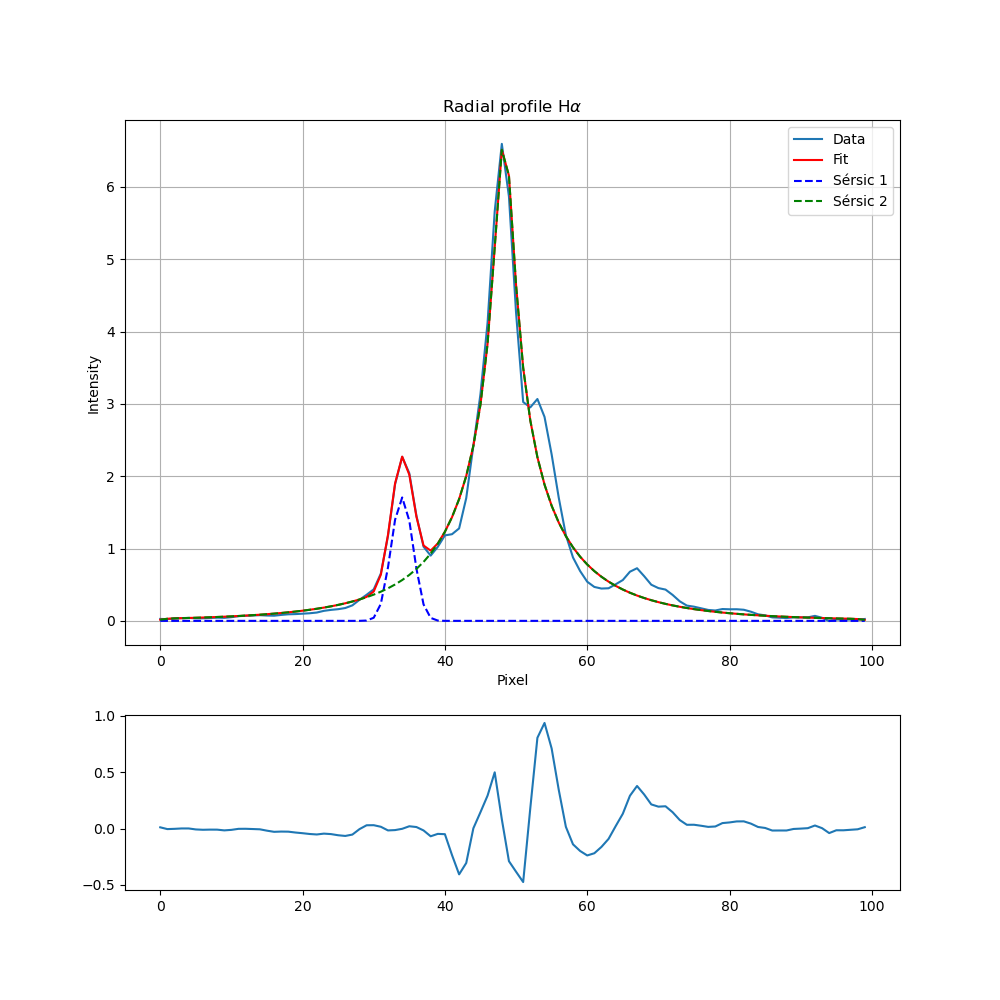

In [13]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [14]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 55),   
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 1697.506380630098
differential_evolution step 2: f(x)= 1112.4431620441335
differential_evolution step 3: f(x)= 1112.4431620441335
differential_evolution step 4: f(x)= 848.7834876777308
differential_evolution step 5: f(x)= 123.93801273836861
differential_evolution step 6: f(x)= 123.93801273836861
differential_evolution step 7: f(x)= 123.93801273836861
differential_evolution step 8: f(x)= 75.29700293904197
differential_evolution step 9: f(x)= 50.698724630219594
differential_evolution step 10: f(x)= 50.698724630219594
differential_evolution step 11: f(x)= 50.698724630219594
differential_evolution step 12: f(x)= 50.698724630219594
differential_evolution step 13: f(x)= 50.698724630219594
differential_evolution step 14: f(x)= 39.517087183148405
differential_evolution step 15: f(x)= 39.517087183148405
differential_evolution step 16: f(x)= 39.517087183148405
differential_evolution step 17: f(x)= 39.517087183148405
differential_evolution step 18: f(x)= 28.56

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\3127802243.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3353, r_e=4.0564, n=1.3315, x_0=34.1761
Sérsic 2: I_e=1.1951, r_e=4.8091, n=1.0842, x_0=47.8149
Sérsic 3: I_e=0.0797, r_e=35.6264, n=1.9631, x_0=53.6467
[ 0.13141573  1.02161348  0.31019985  0.12858019  0.23955952  0.74040195
  0.14823183  0.0975842   0.03712805 10.23748216  0.39592288  0.03547785]
60.861370246051365
88.4475771426031 60.861370246051365 116.12341247790846 12


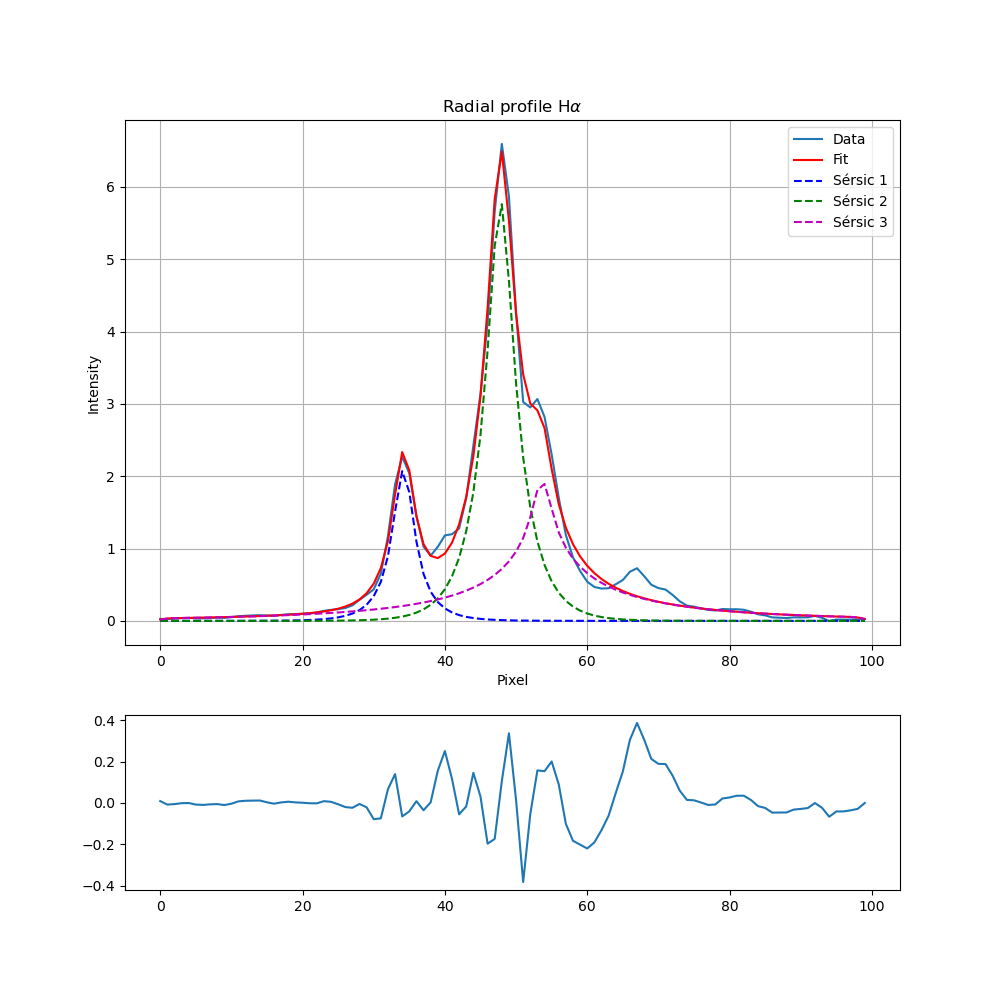

In [15]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75)   
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 6795.561183450244
differential_evolution step 2: f(x)= 6795.561183450244
differential_evolution step 3: f(x)= 5437.182803896451
differential_evolution step 4: f(x)= 5437.182803896451
differential_evolution step 5: f(x)= 2331.650152930647
differential_evolution step 6: f(x)= 1380.7988352092118
differential_evolution step 7: f(x)= 1380.7988352092118
differential_evolution step 8: f(x)= 414.6170704934609
differential_evolution step 9: f(x)= 414.6170704934609
differential_evolution step 10: f(x)= 61.55309701139785
differential_evolution step 11: f(x)= 61.55309701139785
differential_evolution step 12: f(x)= 61.55309701139785
differential_evolution step 13: f(x)= 61.55309701139785
differential_evolution step 14: f(x)= 61.55309701139785
differential_evolution step 15: f(x)= 61.55309701139785
differential_evolution step 16: f(x)= 61.55309701139785
differential_evolution step 17: f(x)= 57.28457021556854
differential_evolution step 18: f(x)= 57.28457021556854

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5387, r_e=2.4049, n=0.9971, x_0=34.0341
Sérsic 2: I_e=0.3915, r_e=14.2783, n=1.8889, x_0=47.9586
Sérsic 3: I_e=0.7677, r_e=1.7729, n=0.5199, x_0=53.8730
Sérsic 4: I_e=0.0147, r_e=29.9889, n=2.2780, x_0=67.3855
[1.21329547e-01 3.16086653e-01 1.80714799e-01 6.18668318e-02
 3.93740979e-02 1.04816642e+00 7.49161005e-02 4.82212636e-02
 2.13684345e-01 2.65079628e-01 2.13681149e-01 1.20686254e-01
 1.14197648e-02 1.90444443e+01 5.78015731e-01 2.01387882e-01]
15.747138944830912
54.301355812300784 15.747138944830912 89.42986192064038 16


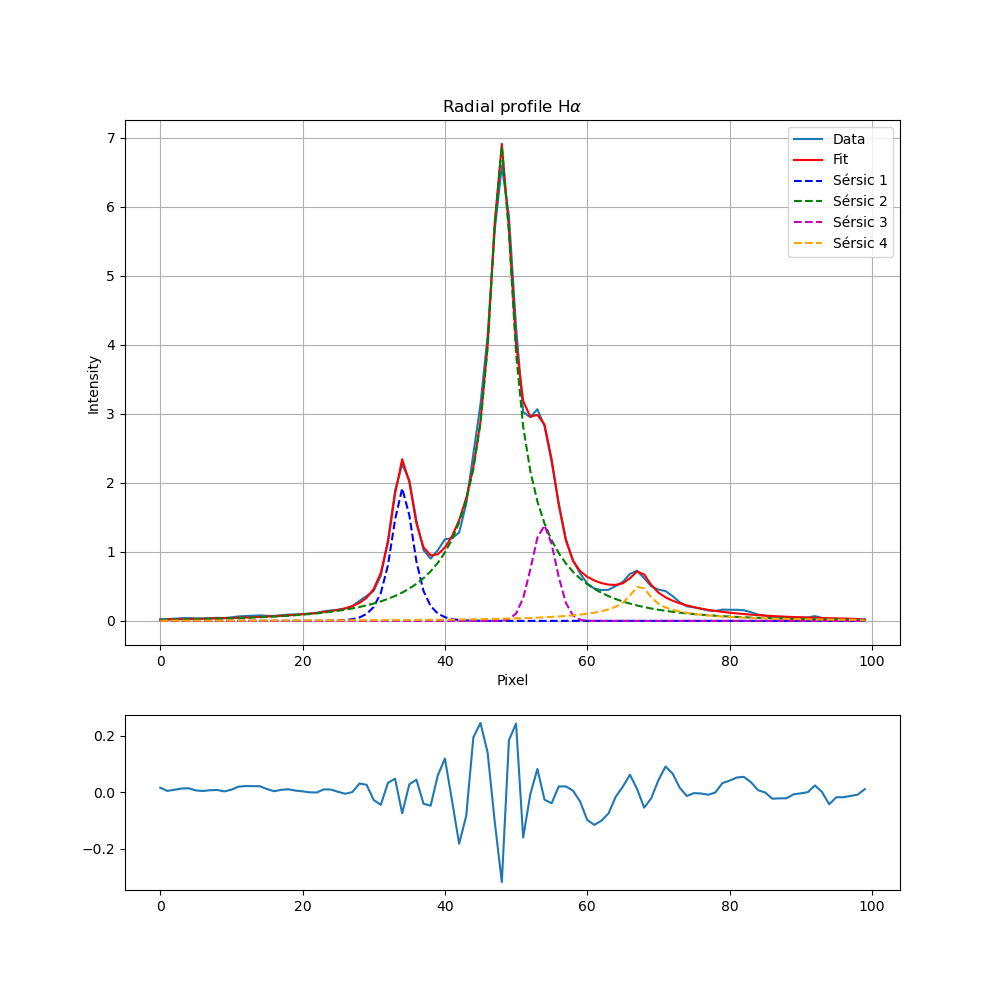

In [18]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, 
                                         sigma = radial_profile_error_HA, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [22]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (51, 54),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75), 

    (0, 20),
    (0, 50),
    (0.1, 10),
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 133530.00690964592
differential_evolution step 2: f(x)= 76132.42281013026
differential_evolution step 3: f(x)= 46349.10589071501
differential_evolution step 4: f(x)= 46230.67610085718
differential_evolution step 5: f(x)= 43246.53266792559
differential_evolution step 6: f(x)= 20817.716878505933
differential_evolution step 7: f(x)= 20817.716878505933
differential_evolution step 8: f(x)= 15108.82465097496
differential_evolution step 9: f(x)= 6296.001701802857
differential_evolution step 10: f(x)= 1823.1539835010965
differential_evolution step 11: f(x)= 1823.1539835010965
differential_evolution step 12: f(x)= 1823.1539835010965
differential_evolution step 13: f(x)= 1823.1539835010965
differential_evolution step 14: f(x)= 1823.1539835010965
differential_evolution step 15: f(x)= 1823.1539835010965
differential_evolution step 16: f(x)= 1823.1539835010965
differential_evolution step 17: f(x)= 472.03934158492245
differential_evolution step 18: f(x)= 472.0393

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\3752501989.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: overflow encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0419, r_e=20.4201, n=2.8488, x_0=34.0839
Sérsic 2: I_e=1.0512, r_e=6.3957, n=1.2167, x_0=48.0065
Sérsic 3: I_e=0.9662, r_e=1.7145, n=0.0618, x_0=53.9173
Sérsic 4: I_e=0.0536, r_e=20.6691, n=1.5337, x_0=67.1168
Sérsic 5: I_e=0.0100, r_e=6.8506, n=3.1588, x_0=56.9394
[1.81467820e-02 6.02987485e+00 3.56580769e-01 5.85438812e-02
 1.31369754e-01 6.13710701e-01 8.88260779e-02 4.72374705e-02
 1.42828087e+01 4.43408636e+00 9.22660823e-01 1.30466311e-01
 1.82077205e-02 4.41153771e+00 2.04260780e-01 2.57925586e-01
 3.93024411e-01 1.73667502e+02 4.57282677e+01 2.98484122e-01]
14.490631581553552
65.12354297395862 14.490631581553552 106.5940353013154 20


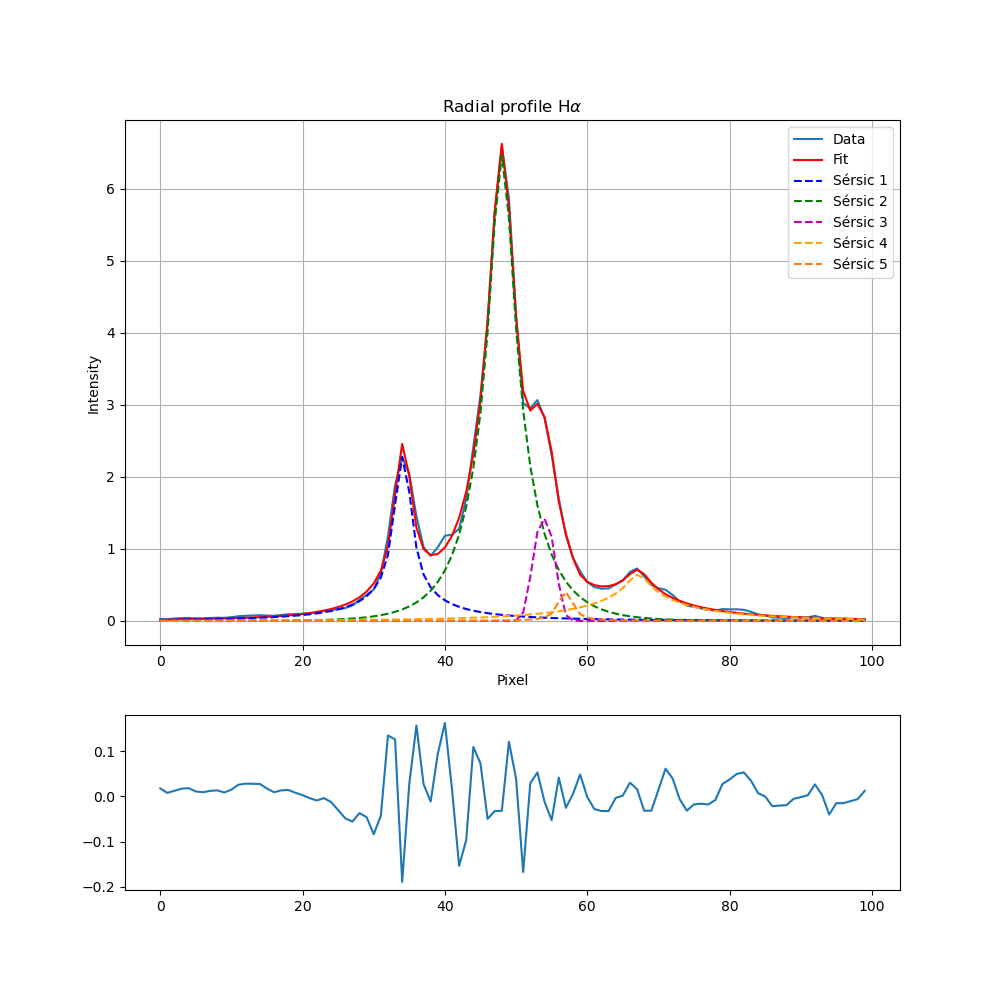

In [24]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, 
                                         sigma = radial_profile_error_HA, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [25]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75), 

    (0, 20),
    (0, 50),
    (0.1, 10),
    (0, 100),
    
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 218765.18689450584
differential_evolution step 2: f(x)= 86587.62068081908
differential_evolution step 3: f(x)= 86587.62068081908
differential_evolution step 4: f(x)= 86587.62068081908
differential_evolution step 5: f(x)= 34176.49615302565
differential_evolution step 6: f(x)= 34176.49615302565
differential_evolution step 7: f(x)= 34176.49615302565
differential_evolution step 8: f(x)= 34176.49615302565
differential_evolution step 9: f(x)= 34176.49615302565
differential_evolution step 10: f(x)= 26839.391912653202
differential_evolution step 11: f(x)= 15562.029040904514
differential_evolution step 12: f(x)= 15562.029040904514
differential_evolution step 13: f(x)= 12594.446606804906
differential_evolution step 14: f(x)= 9642.002048541892
differential_evolution step 15: f(x)= 9642.002048541892
differential_evolution step 16: f(x)= 6292.800996610538
differential_evolution step 17: f(x)= 6292.800996610538
differential_evolution step 18: f(x)= 3675.792044280

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution: [5.95463095e-02 1.44018698e+01 2.49119963e+00 3.40575648e+01
 1.18103133e+00 5.02494085e+00 1.14699924e+00 4.79795886e+01
 7.81902761e-02 1.13026791e+01 2.25846589e+00 5.36717407e+01
 5.11415491e-02 2.09139318e+01 1.55260196e+00 6.70303825e+01
 2.39283214e-01 6.41840756e+00 1.00000000e-01 3.83651077e+01
 1.74437522e+01 1.94978447e-04 7.50234163e+00 5.58996100e+01]
Chi quadro minimo: 0.28829385214301545


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\3428052667.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0099, r_e=60.2974, n=3.6992, x_0=34.0542
Sérsic 2: I_e=1.4726, r_e=3.9354, n=1.0160, x_0=47.9289
Sérsic 3: I_e=0.4153, r_e=4.4715, n=1.1226, x_0=53.8307
Sérsic 4: I_e=0.0759, r_e=15.9027, n=1.3378, x_0=66.9976
Sérsic 5: I_e=0.0267, r_e=7.5275, n=0.0256, x_0=38.6510
Sérsic 6: I_e=10.2819, r_e=0.0002, n=0.1431, x_0=55.8996
[7.10499580e-03 3.14736518e+01 5.47410582e-01 7.91130474e-02
 3.13867207e-01 6.42748352e-01 1.43450922e-01 7.54816394e-02
 1.48103348e-01 1.08789833e+00 2.45777217e-01 1.43311449e-01
 1.71609973e-02 2.44403672e+00 1.45724828e-01 2.28365170e-01
 9.14584335e-01 9.92444350e-01 1.50020322e-01 5.80973701e-01
 3.05563274e+06 3.79079630e+01 3.43192209e+04 2.99067435e+02]
10.4407026755293
74.44070267552931 10.4407026755293 120.9647871392435 24


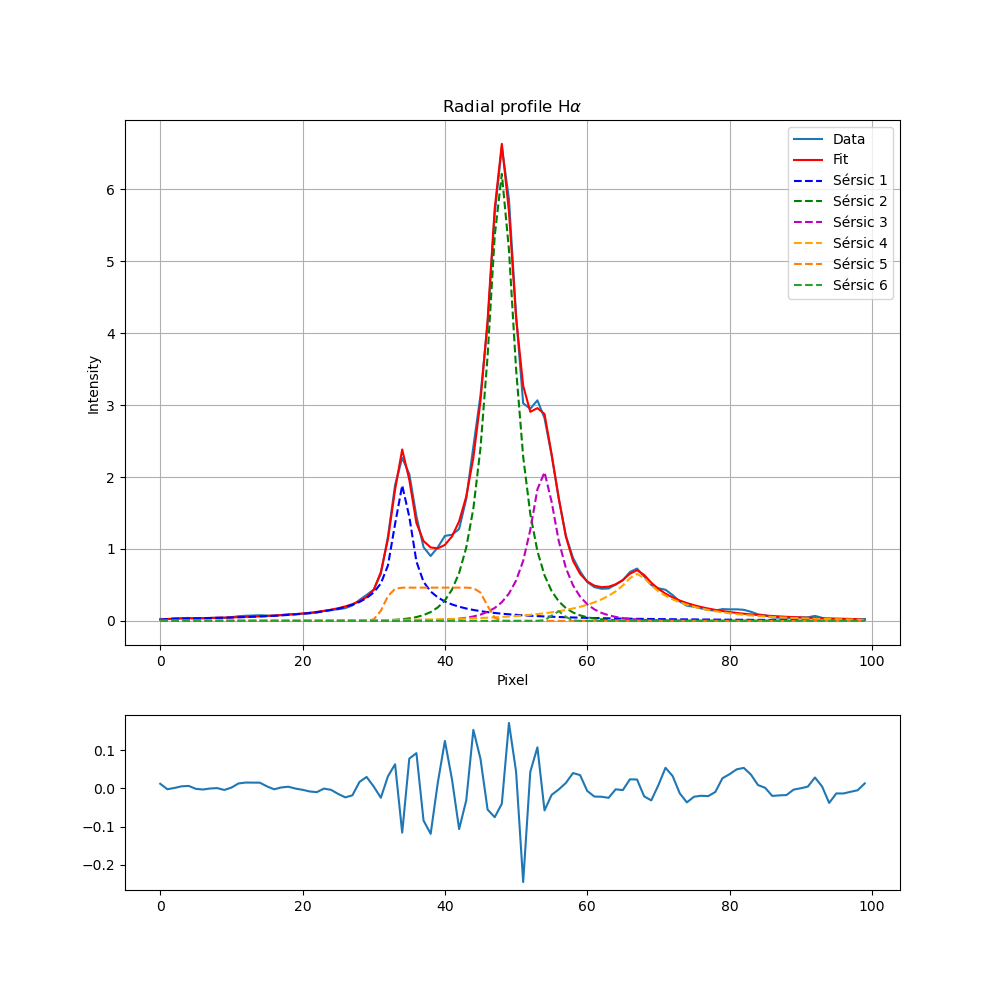

In [27]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, 
                                         sigma = radial_profile_error_HA, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [28]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
   (0, 20),
    (0, 50),
    (0.1, 10),
    (13, 20),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (20, 28),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (30, 38),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (56, 64),
    
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

     (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 820100.2737315552
differential_evolution step 2: f(x)= 331839.61759264965
differential_evolution step 3: f(x)= 123043.79251968906
differential_evolution step 4: f(x)= 123043.79251968906
differential_evolution step 5: f(x)= 123043.79251968906
differential_evolution step 6: f(x)= 123043.79251968906
differential_evolution step 7: f(x)= 123043.79251968906
differential_evolution step 8: f(x)= 123043.79251968906
differential_evolution step 9: f(x)= 77735.94834664252
differential_evolution step 10: f(x)= 77735.94834664252
differential_evolution step 11: f(x)= 77735.94834664252
differential_evolution step 12: f(x)= 40474.81438302594
differential_evolution step 13: f(x)= 37175.380250373404
differential_evolution step 14: f(x)= 37175.380250373404
differential_evolution step 15: f(x)= 37175.380250373404
differential_evolution step 16: f(x)= 37175.380250373404
differential_evolution step 17: f(x)= 37175.380250373404
differential_evolution step 18: f(x)= 29243.8

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\1805296135.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7628\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0079, r_e=0.4278, n=0.4745, x_0=18.7184
Sérsic 2: I_e=0.0175, r_e=65.0495, n=2.0799, x_0=39.6099
Sérsic 3: I_e=0.8235, r_e=1.8655, n=0.6902, x_0=34.0447
Sérsic 4: I_e=1.2185, r_e=4.8802, n=1.1130, x_0=47.9034
Sérsic 5: I_e=0.0673, r_e=28.8808, n=0.0559, x_0=55.1715
Sérsic 6: I_e=0.4227, r_e=3.7013, n=1.0318, x_0=54.0250
Sérsic 7: I_e=0.1725, r_e=4.2858, n=0.7213, x_0=67.0932
[4.32096162e+00 2.04814905e+01 5.33578256e+02 3.51831615e+00
 1.56304674e-02 4.01488260e+01 6.82153696e-01 2.49460823e-02
 1.28657322e-01 1.76841403e-01 1.23544542e-01 5.13665058e-02
 2.00869843e-01 7.49548379e-01 1.14027005e-01 4.12731016e-02
 5.65357346e-02 2.91497801e+00 3.10303583e-02 6.48702739e-01
 1.03608819e-01 7.77333298e-01 1.82742352e-01 9.73182827e-02
 4.33368467e-02 1.04188679e+00 1.86913369e-01 1.96085596e-01]
8.847682908708487
87.7209223453282 8.847682908708487 137.79244811637506 28


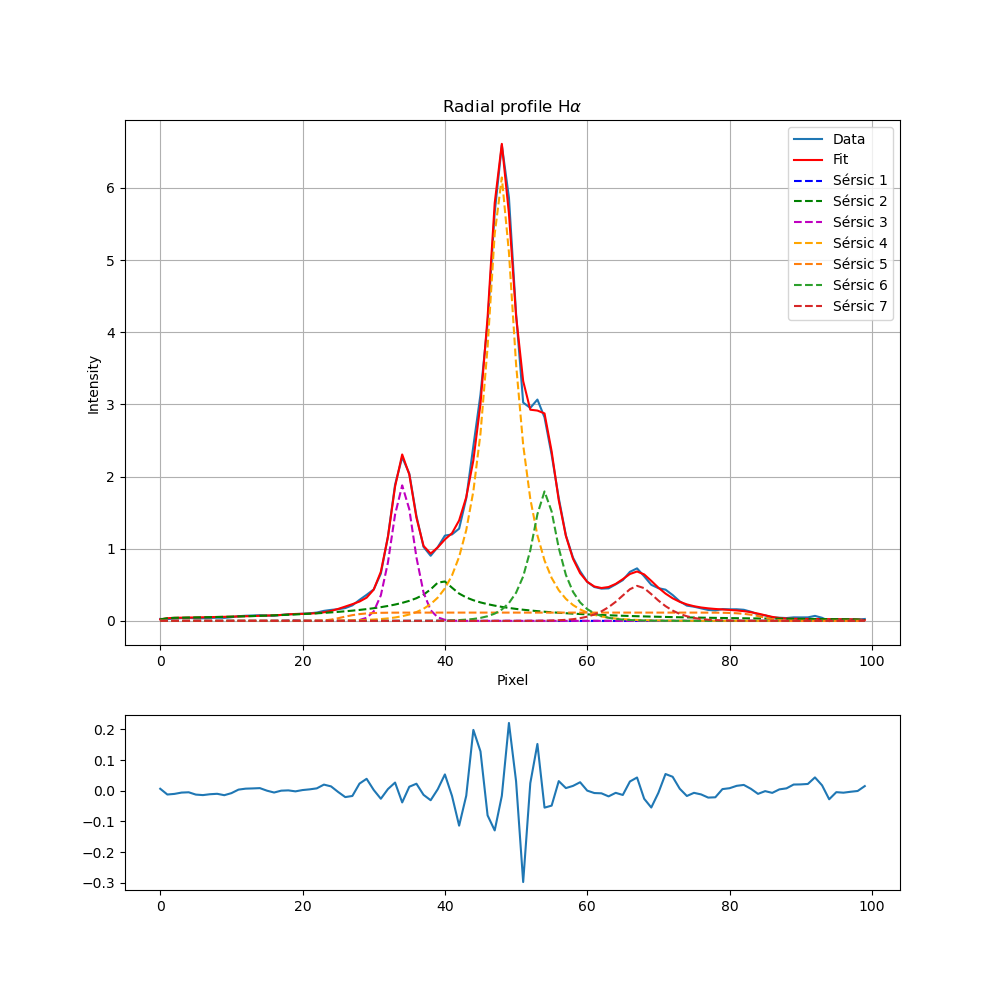

In [29]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

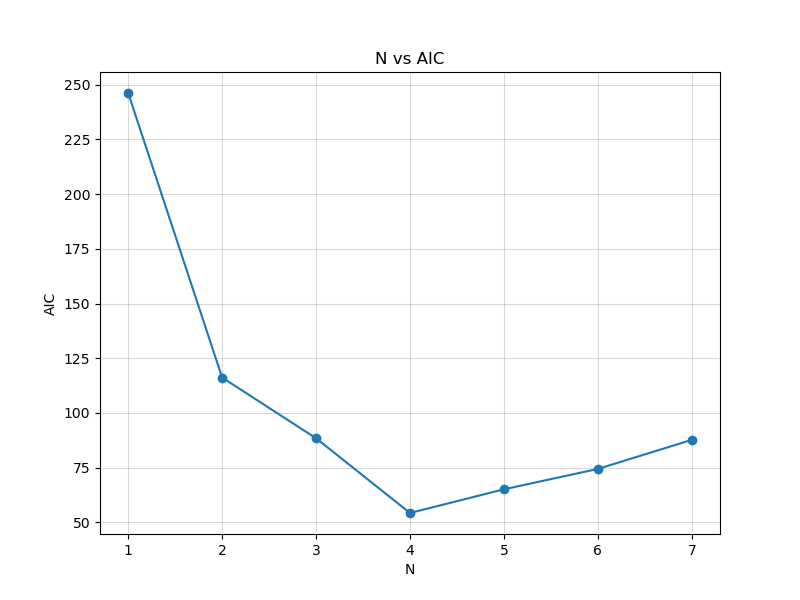

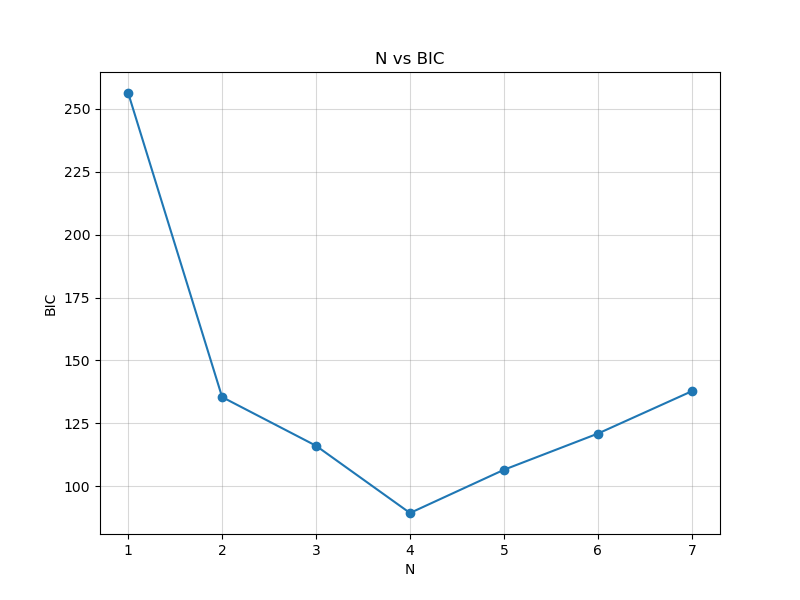

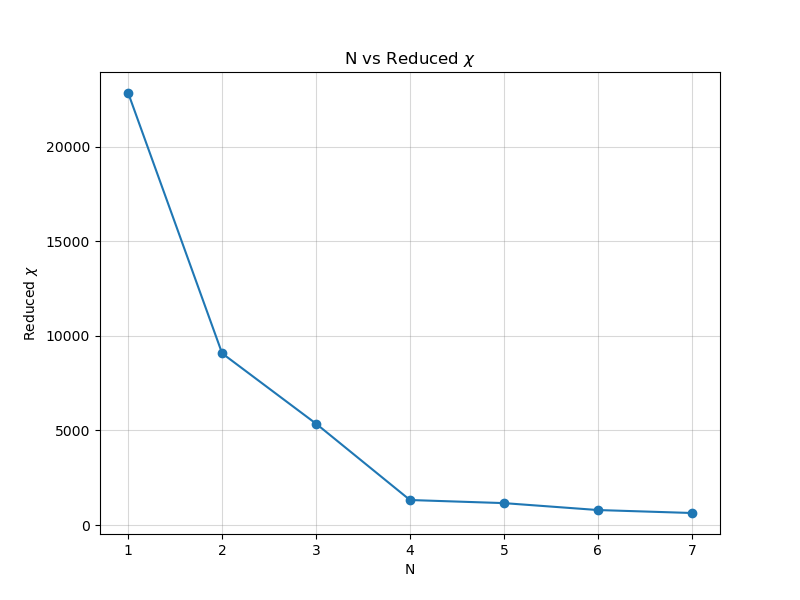

In [31]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N', bbox_inches='tight')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N', bbox_inches='tight')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N', bbox_inches='tight')

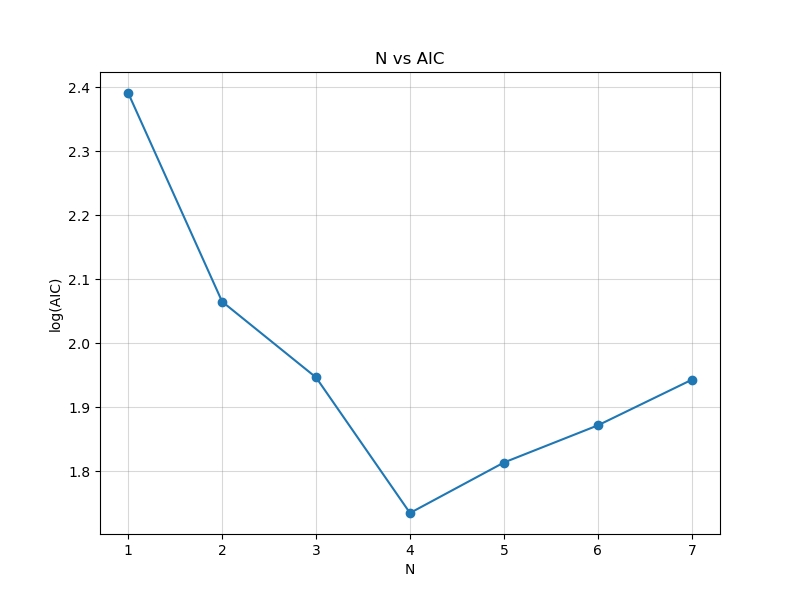

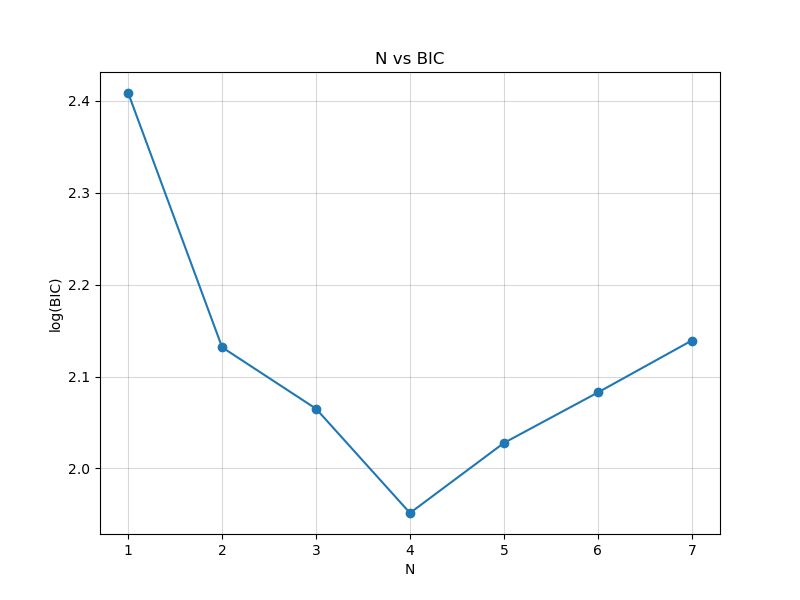

In [32]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log', bbox_inches='tight')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log', bbox_inches='tight')